## What is an energy model?

An energy model assigns a scalar score to an input.

Low energy:
- preferred
- likely
- data-like

High energy:
- less preferred
- unlikely
- not data-like

The model learns an energy landscape.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

torch.manual_seed(42)

PyTorch version: 2.11.0+cpu
CUDA available: False
Using device: cpu


Intuition with a simple hand-made energy

We can define energy of a 2D point as:
E(x, y) = x^2 + y^2

Points near the origin have low energy.
Points far away have high energy.

In [ ]:
def simple_energy(points):
    return (points[:, 0] ** 2 + points[:, 1] ** 2)

In [ ]:
points = torch.tensor([
    [0.0, 0.0],
    [1.0, 1.0],
    [2.0, 2.0],
    [-0.5, 0.5]
])

energies = simple_energy(points)
print(energies)

tensor([0.0000, 2.0000, 8.0000, 0.5000])


In [ ]:
# Visualize a simple energy landscape
x_vals = torch.linspace(-3, 3, 100)
y_vals = torch.linspace(-3, 3, 100)

grid_x, grid_y = torch.meshgrid(x_vals, y_vals, indexing="ij")
grid_points = torch.stack([grid_x.reshape(-1), grid_y.reshape(-1)], dim=1)

grid_energy = simple_energy(grid_points).reshape(100, 100)

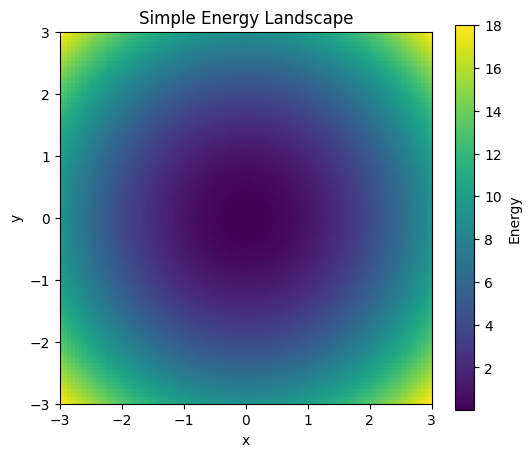

In [ ]:
plt.figure(figsize=(6, 5))
plt.imshow(
    grid_energy.numpy(),
    extent=[-3, 3, -3, 3],
    origin="lower",
    cmap="viridis"
)
plt.colorbar(label="Energy")
plt.title("Simple Energy Landscape")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

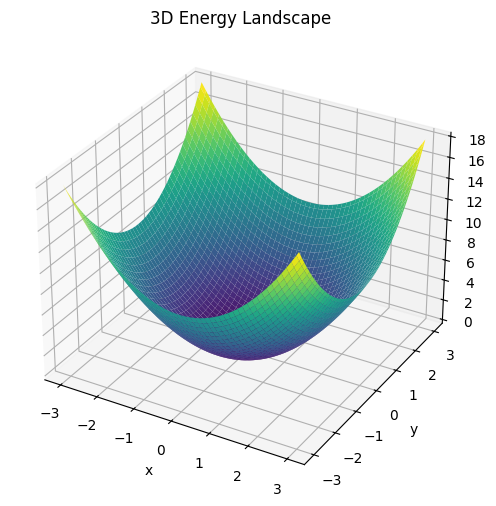

In [ ]:
# 3D view of the energy landscape
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

ax.plot_surface(
    grid_x.numpy(),
    grid_y.numpy(),
    grid_energy.numpy(),
    cmap="viridis",
    linewidth=0,
    antialiased=True
)

ax.set_title("3D Energy Landscape")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("Energy")
plt.show()


Toy data distribution

We create two clusters of 2D points.
These will represent "real data".

In [ ]:
num_points = 500

cluster1 = torch.randn(num_points // 2, 2) * 0.4 + torch.tensor([2.0, 2.0])
cluster2 = torch.randn(num_points // 2, 2) * 0.4 + torch.tensor([-2.0, -2.0])

real_data = torch.cat([cluster1, cluster2], dim=0)

print(real_data.shape)

torch.Size([500, 2])


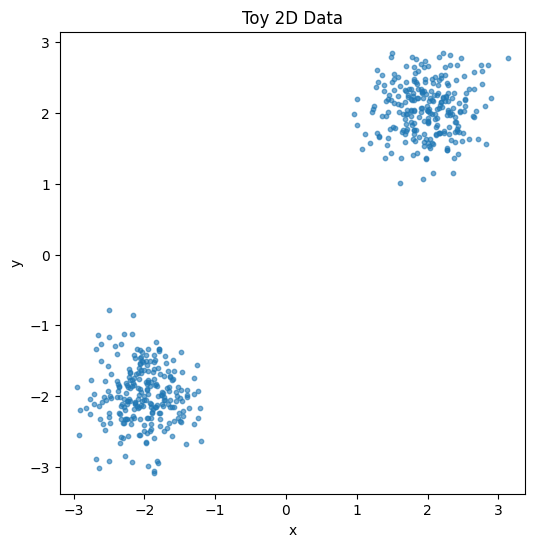

In [ ]:
plt.figure(figsize=(6, 6))
plt.scatter(real_data[:, 0].numpy(), real_data[:, 1].numpy(), s=10, alpha=0.6)
plt.title("Toy 2D Data")
plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")
plt.show()

Build a neural network energy model

Input:
2D point

Output:
one scalar energy

In [ ]:
class EnergyModel(nn.Module):
    def __init__(self, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)

In [ ]:
model = EnergyModel(hidden_dim=64).to(device)
print(model)

EnergyModel(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=1, bias=True)
  )
)


In [ ]:
sample_points = torch.tensor([
    [0.0, 0.0],
    [2.0, 2.0],
    [-2.0, -2.0]
], dtype=torch.float32).to(device)

with torch.no_grad():
    sample_energy = model(sample_points)

print(sample_energy)

tensor([0.1015, 0.0916, 0.0641])


Positive and negative samples

To train an energy model simply, we can use:
- positive samples = real data
- negative samples = random noise points

We want:
- low energy for real data
- high energy for noise

In [ ]:
def sample_negative_points(num_samples):
    return torch.rand(num_samples, 2) * 8 - 4

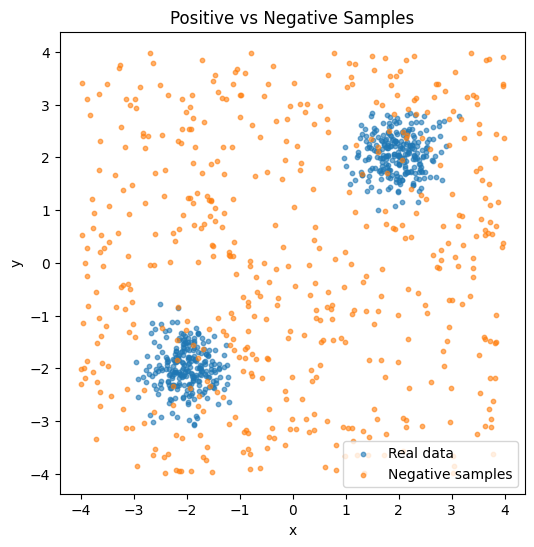

In [ ]:
negative_data = sample_negative_points(500)

plt.figure(figsize=(6, 6))
plt.scatter(real_data[:, 0].numpy(), real_data[:, 1].numpy(), s=10, alpha=0.6, label="Real data")
plt.scatter(negative_data[:, 0].numpy(), negative_data[:, 1].numpy(), s=10, alpha=0.6, label="Negative samples")
plt.legend()
plt.title("Positive vs Negative Samples")
plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")
plt.show()

Simple margin-based loss

We want:
energy(real) to be low
energy(fake) to be high

One simple loss:
loss = mean(E_real) + mean(relu(margin - E_fake))

In [ ]:
def energy_margin_loss(real_energy, fake_energy, margin=1.0):
    loss_real = real_energy.mean()
    loss_fake = torch.relu(margin - fake_energy).mean()
    return loss_real + loss_fake

In [ ]:
real_batch = real_data[:32].to(device)
fake_batch = sample_negative_points(32).to(device)

real_energy = model(real_batch)
fake_energy = model(fake_batch)

loss = energy_margin_loss(real_energy, fake_energy, margin=1.0)
print("loss:", loss.item())

loss: 1.0296220779418945


In [ ]:
# One training step
model = EnergyModel(hidden_dim=64).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)

real_batch = real_data[:64].to(device)
fake_batch = sample_negative_points(64).to(device)

real_energy = model(real_batch)
fake_energy = model(fake_batch)

loss = energy_margin_loss(real_energy, fake_energy, margin=1.0)

optimizer.zero_grad()
loss.backward()
optimizer.step()

print("training step complete")
print("loss:", loss.item())

training step complete
loss: 1.105828881263733


In [ ]:
# Batch sampling helper
def get_real_batch(real_data, batch_size=64):
    indices = torch.randint(0, real_data.shape[0], (batch_size,))
    return real_data[indices]

Full training loop

In [ ]:
model = EnergyModel(hidden_dim=64).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)

loss_history = []
real_energy_history = []
fake_energy_history = []

for step in range(1000):
    real_batch = get_real_batch(real_data, batch_size=128).to(device)
    fake_batch = sample_negative_points(128).to(device)

    real_energy = model(real_batch)
    fake_energy = model(fake_batch)

    loss = energy_margin_loss(real_energy, fake_energy, margin=1.0)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())
    real_energy_history.append(real_energy.mean().item())
    fake_energy_history.append(fake_energy.mean().item())

    if step % 100 == 0:
        print(
            f"Step {step:04d} | "
            f"Loss: {loss.item():.4f} | "
            f"Real Energy: {real_energy.mean().item():.4f} | "
            f"Fake Energy: {fake_energy.mean().item():.4f}"
        )

Step 0000 | Loss: 0.9431 | Real Energy: -0.1568 | Fake Energy: -0.0999
Step 0100 | Loss: -11.3358 | Real Energy: -18.4365 | Fake Energy: -3.9206
Step 0200 | Loss: -72.4665 | Real Energy: -118.7725 | Fake Energy: -26.8512
Step 0300 | Loss: -279.6728 | Real Energy: -431.0315 | Fake Energy: -85.3977
Step 0400 | Loss: -642.0957 | Real Energy: -1008.6377 | Fake Energy: -216.7801
Step 0500 | Loss: -1098.2236 | Real Energy: -1952.9208 | Fake Energy: -606.8989
Step 0600 | Loss: -1846.5688 | Real Energy: -3460.1567 | Fake Energy: -1224.2458
Step 0700 | Loss: -2789.2136 | Real Energy: -5003.5889 | Fake Energy: -1645.2300
Step 0800 | Loss: -4537.3130 | Real Energy: -7702.6035 | Fake Energy: -2109.6521
Step 0900 | Loss: -6364.6865 | Real Energy: -10671.8086 | Fake Energy: -2935.0210


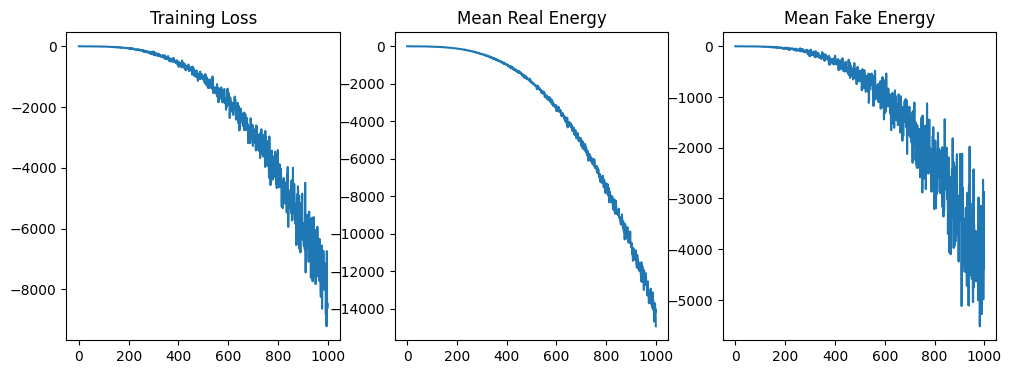

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.plot(loss_history)
plt.title("Training Loss")

plt.subplot(1, 3, 2)
plt.plot(real_energy_history)
plt.title("Mean Real Energy")

plt.subplot(1, 3, 3)
plt.plot(fake_energy_history)
plt.title("Mean Fake Energy")

plt.show()

 Visualize learned energy landscape

In [ ]:
with torch.no_grad():
    grid_energy = model(grid_points.to(device)).cpu().reshape(100, 100)

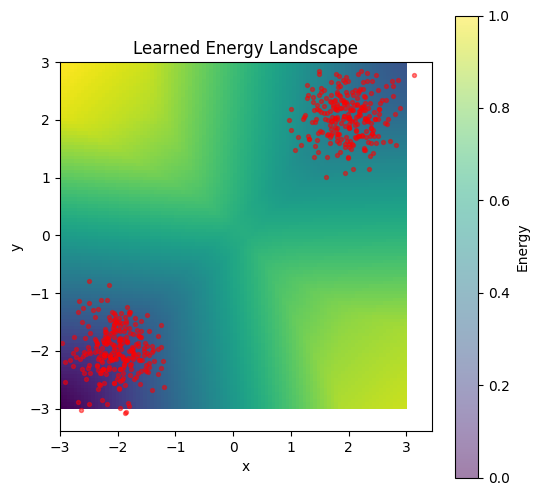

In [ ]:
plt.figure(figsize=(6, 6))
plt.imshow(
    grid_energy.numpy(),
    extent=[-3, 3, -3, 3],
    origin="lower",
    cmap="viridis"
)
plt.scatter(real_data[:, 0].numpy(), real_data[:, 1].numpy(), s=8, c="red", alpha=0.5)
plt.colorbar(label="Energy")
plt.title("Learned Energy Landscape")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

3D learned energy surface

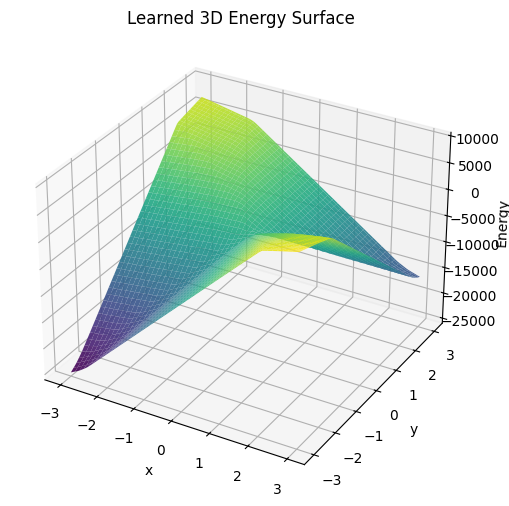

In [ ]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

ax.plot_surface(
    grid_x.numpy(),
    grid_y.numpy(),
    grid_energy.numpy(),
    cmap="viridis",
    linewidth=0,
    antialiased=True,
    alpha=0.9
)

ax.set_title("Learned 3D Energy Surface")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("Energy")
plt.show()

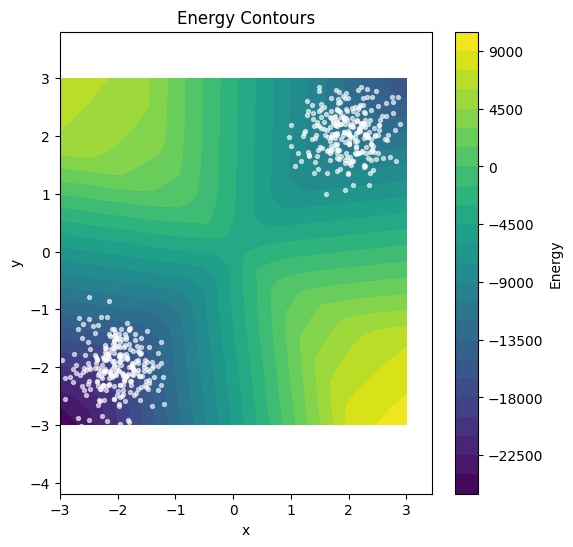

In [ ]:
# Contour plot is often easier to read
plt.figure(figsize=(6, 6))
contours = plt.contourf(
    grid_x.numpy(),
    grid_y.numpy(),
    grid_energy.numpy(),
    levels=30,
    cmap="viridis"
)
plt.scatter(real_data[:, 0].numpy(), real_data[:, 1].numpy(), s=8, c="white", alpha=0.6)
plt.colorbar(contours, label="Energy")
plt.title("Energy Contours")
plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")
plt.show()

Compare energy on real vs fake samples

In [ ]:
with torch.no_grad():
    real_eval = model(real_data.to(device)).cpu()
    fake_eval = model(sample_negative_points(real_data.shape[0]).to(device)).cpu()

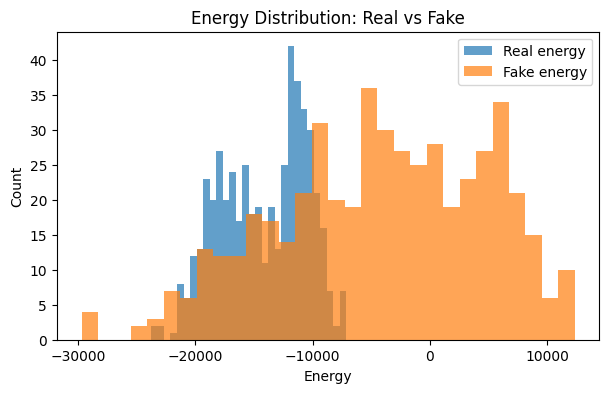

In [ ]:
plt.figure(figsize=(7, 4))
plt.hist(real_eval.numpy(), bins=30, alpha=0.7, label="Real energy")
plt.hist(fake_eval.numpy(), bins=30, alpha=0.7, label="Fake energy")
plt.legend()
plt.title("Energy Distribution: Real vs Fake")
plt.xlabel("Energy")
plt.ylabel("Count")
plt.show()

In [ ]:
# See which points have low energy
with torch.no_grad():
    random_points = sample_negative_points(1000)
    energies = model(random_points.to(device)).cpu()

lowest_indices = torch.argsort(energies)[:100]
lowest_points = random_points[lowest_indices]

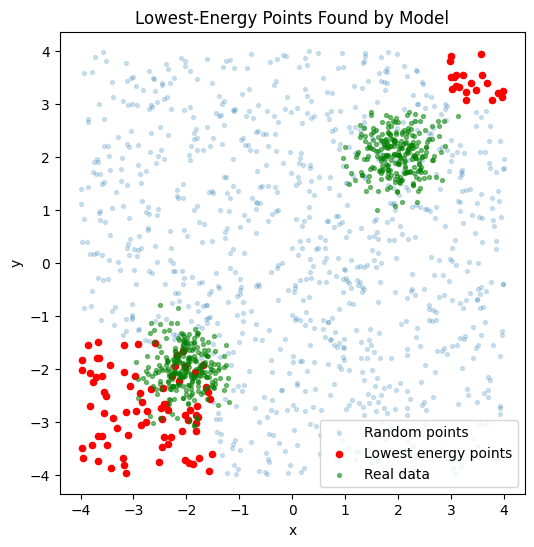

In [ ]:
plt.figure(figsize=(6, 6))
plt.scatter(random_points[:, 0].numpy(), random_points[:, 1].numpy(), s=8, alpha=0.2, label="Random points")
plt.scatter(lowest_points[:, 0].numpy(), lowest_points[:, 1].numpy(), s=20, c="red", label="Lowest energy points")
plt.scatter(real_data[:, 0].numpy(), real_data[:, 1].numpy(), s=8, c="green", alpha=0.5, label="Real data")
plt.legend()
plt.title("Lowest-Energy Points Found by Model")
plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")
plt.show()

Gradient of energy with respect to input

This is important intuition:
the model defines an energy surface,
and gradients tell us how energy changes in input space.

In [ ]:
point = torch.tensor([[0.0, 0.0]], dtype=torch.float32, requires_grad=True).to(device)

energy = model(point)
energy.backward()

print("energy:", energy.item())
print("gradient wrt input:", point.grad)

energy: -3630.72802734375
gradient wrt input: tensor([[1517.0291, 1339.9742]])


Energy descent intuition

If we move a point in the direction of negative gradient,
we may move toward lower-energy regions.


In [ ]:
def descend_energy(model, start_point, steps=20, step_size=0.1):
    points = []

    x = start_point.clone().detach().to(device)
    x.requires_grad_(True)

    for _ in range(steps):
        points.append(x.detach().cpu().clone())

        energy = model(x).sum()
        energy.backward()

        with torch.no_grad():
            x -= step_size * x.grad

        x.grad.zero_()

    return torch.cat(points, dim=0)

In [ ]:
start_point = torch.tensor([[3.0, -3.0]], dtype=torch.float32)
trajectory = descend_energy(model, start_point, steps=30, step_size=0.05)

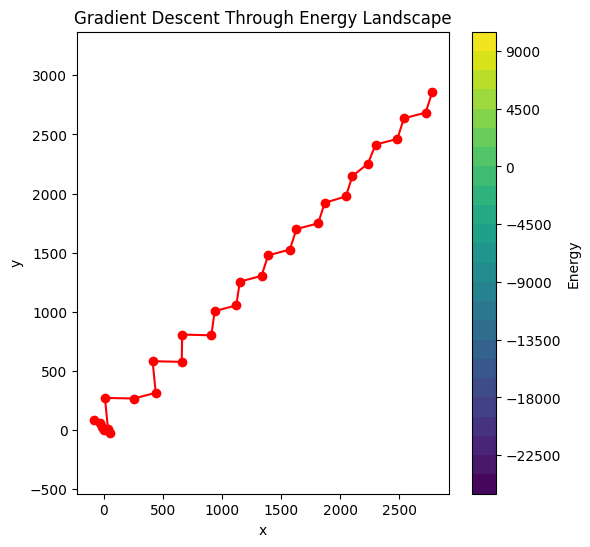

In [ ]:
plt.figure(figsize=(6, 6))
contours = plt.contourf(
    grid_x.numpy(),
    grid_y.numpy(),
    grid_energy.numpy(),
    levels=30,
    cmap="viridis"
)
plt.colorbar(contours, label="Energy")

plt.plot(trajectory[:, 0].numpy(), trajectory[:, 1].numpy(), marker="o", color="red")
plt.scatter(real_data[:, 0].numpy(), real_data[:, 1].numpy(), s=8, c="white", alpha=0.4)

plt.title("Gradient Descent Through Energy Landscape")
plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")
plt.show()

Hyperparameter Sweep

In [ ]:
def train_energy_model(real_data, margin=1.0, steps=400, lr=0.001, hidden_dim=64):
    model = EnergyModel(hidden_dim=hidden_dim).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)

    loss_history = []

    for step in range(steps):
        real_batch = get_real_batch(real_data, batch_size=128).to(device)
        fake_batch = sample_negative_points(128).to(device)

        real_energy = model(real_batch)
        fake_energy = model(fake_batch)

        loss = energy_margin_loss(real_energy, fake_energy, margin=margin)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        loss_history.append(loss.item())

    return model, loss_history

In [ ]:
margins = [0.5, 1.0, 2.0]
margin_histories = {}

for margin in margins:
    _, history = train_energy_model(real_data, margin=margin, steps=300)
    margin_histories[margin] = history

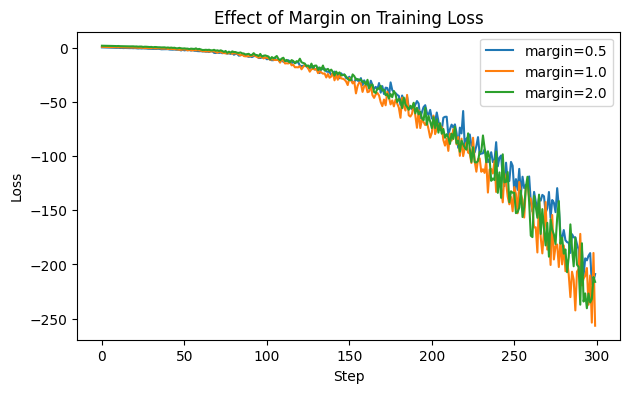

In [ ]:
plt.figure(figsize=(7, 4))
for margin in margins:
    plt.plot(margin_histories[margin], label=f"margin={margin}")
plt.legend()
plt.title("Effect of Margin on Training Loss")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.show()

In [ ]:
learning_rates = [0.0005, 0.001, 0.005]
margins = [0.5, 1.0, 2.0]

results = torch.zeros(len(learning_rates), len(margins))

In [ ]:
for i, lr in enumerate(learning_rates):
    for j, margin in enumerate(margins):
        _, history = train_energy_model(real_data, margin=margin, steps=150, lr=lr)
        results[i, j] = history[-1]

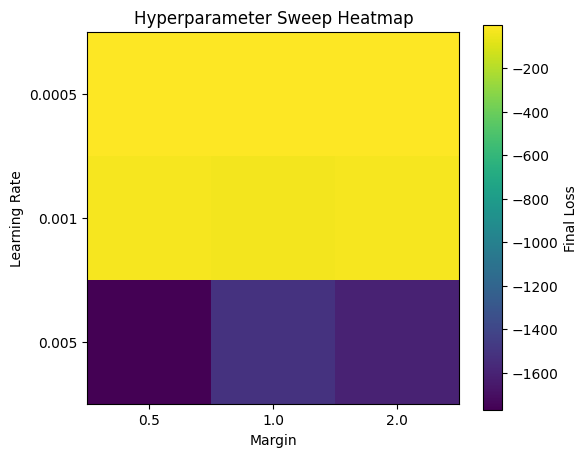

In [ ]:
plt.figure(figsize=(6, 5))
plt.imshow(results.numpy(), cmap="viridis")
plt.colorbar(label="Final Loss")
plt.xticks(range(len(margins)), margins)
plt.yticks(range(len(learning_rates)), learning_rates)
plt.xlabel("Margin")
plt.ylabel("Learning Rate")
plt.title("Hyperparameter Sweep Heatmap")
plt.show()